<div dir ='rtl'>
قبل از هرچیزی لازم به توضیح هست که در تمرین قبلی نیاز بوده که scaler که روی داده‌های train اعمال شده بود را ذخیره کنم ولی متاسفانه انجام نشده بود که برای این تمرین و جلوگیری از نشت اطلاعات داده‌‌های تست این تصحیح در کد قبلی پیاده سازی شد و در این تمرین از این scaler که به اسم "scaler_train.save" ذخیره شده‌است استفاده کرده‌ام. 
    <br>
    کد تمرین قبلی نیز اصلاح و در فایل این تمرین اضافه شده‌است.
    

In [2]:
!pip install xgboost lightgbm catboost

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import joblib
import seaborn as sns
from sklearn.kernel_approximation import Nystroem
from sklearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from statsmodels.nonparametric.kernel_regression import KernelReg
import warnings
import xgboost as xgb

from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC,SVC,SVR
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, log_loss, confusion_matrix, classification_report, roc_auc_score,
                             mean_squared_error, mean_absolute_error, r2_score,roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge,LogisticRegression
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor,RandomForestClassifier,AdaBoostClassifier
from sklearn.tree import DecisionTreeRegressor,DecisionTreeClassifier
warnings.filterwarnings('ignore')
from sklearn.naive_bayes import GaussianNB


In [4]:
bank_CleanData= pd.read_csv('train_data.csv')
test_data=pd.read_csv('test_data.csv')



<div dir = 'rtl'>
    <h1>
 اماده‌سازی داده‌های تست 
    </h1>
</div>

<div dir='rtl'>
    در قسمت زیر برای یکسان کردن ستون و ویژگی‌ها دیتا تست و شبیه کردن به دیتا Train تلاش شده‌است تا در قسمت‌های بعدی راحت‌تر باشیم.
    <br>
    کدها همان کدهایی می‌باشد که روی داده‌های ترین پیاده شده بود.
    <br>
    داده‌ها تست نیز در تمرین قبلی برای جلوگیری از نشت اطلاعات جدا شده بود.
    

In [5]:
test_data['total_contacts'] = test_data['campaign'] + test_data['previous']
test_data['total_contacts_bin'] = pd.cut(test_data['total_contacts'], bins=10)
test_data['campaign_to_previous_ratio'] = test_data['campaign'] / (test_data['previous'] + 1)
test_data['ratio_bin'] = pd.qcut(test_data['campaign_to_previous_ratio'], q=10, duplicates='drop')
test_data['age_group'] = pd.cut(
    test_data['age'],
    bins=[0, 19, 29, 39, 49, 59,100],
    labels=['<19', '19-29', '29-39', '39-49', '49-59','<60']
)
test_data['economic_spread'] = test_data['nr.employed'] - test_data['euribor3m']
test_data['economic_spread_bin'] = pd.qcut(test_data['economic_spread'], q=10, duplicates='drop')
test_data['employment_rate_change'] = test_data['emp.var.rate'] * test_data['euribor3m']

test_data['consumer_sentiment_economic_idx'] = (
    test_data['cons.conf.idx'] - test_data['cons.price.idx']
)

test_data['economic_conditions_proxy'] = (
    test_data['euribor3m'] * test_data['cons.price.idx']
)

test_data['inflation_to_employment_ratio'] = (
    test_data['cons.price.idx'] / test_data['nr.employed']
)

test_data['sentiment_adjusted_employment'] = (
    test_data['nr.employed'] * test_data['cons.conf.idx']
)

test_data['real_activity_index'] = (
    test_data['emp.var.rate'] * test_data['cons.price.idx']
)

test_data['labor_market_pressure'] = (
    test_data['nr.employed'] / (test_data['euribor3m'] + 1)
)

In [6]:
scaler = joblib.load('scaler_train.save')
test_columns = joblib.load('train_columns.save')
num_cols = [
    'age', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx',
    'cons.conf.idx', 'euribor3m', 'nr.employed'
]
test_data[num_cols] = scaler.transform(test_data[num_cols])

all_month_cols = [
    'month_aug', 'month_dec', 'month_jul', 'month_jun', 
    'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep'
]
days = [
    'day_of_week_mon',
    'day_of_week_thu',
    'day_of_week_tue',
    'day_of_week_wed'
]
job_cols = [
    'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 
    'job_management', 'job_retired', 'job_self-employed', 
    'job_services', 'job_student', 'job_technician', 'job_unemployed'
]
edu_cols = [
    'education_basic.6y', 'education_basic.9y', 'education_high.school', 
    'education_illiterate', 'education_professional.course', 
    'education_university.degree', 'education_unknown'
]

test_data['month_apr'] = (test_data[all_month_cols].sum(axis=1) == 0).astype(int)
test_data['job_admin'] = (test_data[job_cols].sum(axis=1) == 0).astype(int)
test_data['education_basic.4y'] = (test_data[edu_cols].sum(axis=1) == 0).astype(int)

cols_to_drop = ['campaign','age','pdays','cons.price.idx','cons.conf.idx']+['emp.var.rate','euribor3m','nr.employed','economic_conditions_proxy']
test_data=test_data.drop(columns=['marital_married','marital_single'])
test_data=test_data.drop(columns=days+['loan_yes','housing_yes'])
test_data = test_data.drop(columns=cols_to_drop)
test_data=test_data.drop(columns=['poutcome_nonexistent','poutcome_success','economic_spread_bin'])
test_data['total_contacts_bin'] = test_data['total_contacts_bin'].astype(object)
test_data['ratio_bin'] = test_data['ratio_bin'].astype(object)
test_data['age_group'] = test_data['age_group'].astype(object)
test_data['total_contacts'] = test_data['total_contacts'].astype('Int64')

<div dir = 'rtl'>
    <h1>
    اماده‌سازی دیتافریم‌های مناسب برای ایجاد مدل‌هایی برپایه رگرسیون و تصمیم‌گیری درختی
    </h1>
</div>

<div dir ='rtl'>
    در دو سلکشن زیر تصمیم گرفتم برای مدل‌های خطی و درختی دو دیتافریم جدا و مناسب برای هرکدوم بسازم که برای مدل درختی این ستون‌هایی که براساس onehot encoding وجود داشتن رو تجمیع کرده و براساس شماره مشخص کردیم زیرا اینکار برای مدل درختی که براساس تصمیم گیری‌های خطی می‌باشد بهتر است زیرا انگار تعداد ویژگی ها رو کم کرده‌ایم.
    <br>
    این کار برای هردو دیتاست train , test  انجام داده شده‌است.

In [16]:
job_cols = [col for col in bank_CleanData.columns if col.startswith('job_')]
edu_cols = [col for col in bank_CleanData.columns if col.startswith('education_')]
month_cols = [col for col in bank_CleanData.columns if col.startswith('month_')]
def combine_binary_columns(bank_CleanData, col_list, prefix_to_remove, new_col_name):
    combined = pd.Series(index=bank_CleanData.index, dtype='object')
    for col in col_list:
        category = col.replace(prefix_to_remove, '')
        mask = bank_CleanData[col].astype(bool)
        combined[mask] = category
    combined.fillna('unknown', inplace=True) 
    return combined
df_processed = bank_CleanData.copy()
df_processed['job'] = combine_binary_columns(df_processed, job_cols, 'job_', 'job')
df_processed['education'] = combine_binary_columns(df_processed, edu_cols, 'education_', 'education')
df_processed['month'] = combine_binary_columns(df_processed, month_cols, 'month_', 'month')
df_processed.drop(columns=job_cols + edu_cols + month_cols, inplace=True)

df_linear = pd.get_dummies(
    df_processed,
    columns=['job', 'education', 'month'],
    drop_first=True, 
    dtype=int        
)
df_tree = df_processed.copy()
le_job = LabelEncoder()
le_edu = LabelEncoder()
le_month = LabelEncoder()

df_tree['job_enc'] = le_job.fit_transform(df_tree['job'])
df_tree['education_enc'] = le_edu.fit_transform(df_tree['education'])
df_tree['month_enc'] = le_month.fit_transform(df_tree['month'])
df_tree.drop(columns=['job', 'education', 'month'], inplace=True)

print("شکل دیتافریم خطی:", df_linear.info())
print("شکل دیتافریم درختی:", df_tree.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31842 entries, 0 to 31841
Data columns (total 43 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   previous                         31842 non-null  float64
 1   has_prev_contact                 31842 non-null  int64  
 2   pdays_real                       1170 non-null   float64
 3   contact_telephone                31842 non-null  bool   
 4   y                                31842 non-null  int64  
 5   total_contacts                   31842 non-null  float64
 6   total_contacts_bin               31842 non-null  object 
 7   campaign_to_previous_ratio       31842 non-null  float64
 8   ratio_bin                        31842 non-null  object 
 9   age_group                        31842 non-null  object 
 10  economic_spread                  31842 non-null  float64
 11  employment_rate_change           31842 non-null  float64
 12  consumer_sentiment

In [17]:
if 'pdays_real' in test_data.columns:
    test_data['pdays_real'] = test_data['pdays_real'].fillna(-1)
job_cols_test = [col for col in test_data.columns if col.startswith('job_')]
edu_cols_test = [col for col in test_data.columns if col.startswith('education_')]
month_cols_test = [col for col in test_data.columns if col.startswith('month_')]

def combine_binary_columns(df, col_list, prefix_to_remove):
    combined = pd.Series(index=df.index, dtype='object')
    for col in col_list:
        category = col.replace(prefix_to_remove, '')
        mask = df[col].astype(bool)
        combined[mask] = category
    combined.fillna('unknown', inplace=True)
    return combined

test_processed = test_data.copy() 

test_processed['job'] = combine_binary_columns(test_processed, job_cols_test, 'job_')
test_processed['education'] = combine_binary_columns(test_processed, edu_cols_test, 'education_')
test_processed['month'] = combine_binary_columns(test_processed, month_cols_test, 'month_')

test_processed.drop(columns=job_cols_test + edu_cols_test + month_cols_test, inplace=True)

df_test_linear = pd.get_dummies(
    test_processed,
    columns=['job', 'education', 'month'],
    drop_first=True,
    dtype=int
)

train_linear_cols = joblib.load('train_linear_columns.save')

for col in train_linear_cols:
    if col not in df_test_linear.columns:
        df_test_linear[col] = 0
df_test_linear = df_test_linear[train_linear_cols]
le_job = joblib.load('le_job.save')
le_edu = joblib.load('le_edu.save')
le_month = joblib.load('le_month.save')

df_test_tree = test_processed.copy()  
df_test_tree['job_enc'] = le_job.transform(df_test_tree['job'])
df_test_tree['education_enc'] = le_edu.transform(df_test_tree['education'])
df_test_tree['month_enc'] = le_month.transform(df_test_tree['month'])

df_test_tree.drop(columns=['job', 'education', 'month'], inplace=True)
print("شکل دیتافریم خطی تست:", df_test_linear.shape)
print("شکل دیتافریم درختی تست:", df_test_tree.shape)

X_test_linear = df_test_linear.drop('y', axis=1)
y_test = df_test_linear['y']
X_test_tree = df_test_tree.drop('y', axis=1)
y_test_tree = df_test_tree['y']

شکل دیتافریم خطی تست: (7961, 43)
شکل دیتافریم درختی تست: (7961, 20)


In [18]:
print(df_test_tree.info())
print(df_test_linear.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7961 entries, 0 to 7960
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   previous                         7961 non-null   float64
 1   has_prev_contact                 7961 non-null   int64  
 2   pdays_real                       7961 non-null   float64
 3   contact_telephone                7961 non-null   bool   
 4   y                                7961 non-null   int64  
 5   total_contacts                   7961 non-null   Int64  
 6   total_contacts_bin               7961 non-null   object 
 7   campaign_to_previous_ratio       7961 non-null   float64
 8   ratio_bin                        7961 non-null   object 
 9   age_group                        7961 non-null   object 
 10  economic_spread                  7961 non-null   float64
 11  employment_rate_change           7961 non-null   float64
 12  consumer_sentiment_e

In [10]:
joblib.dump(le_job, 'le_job.save')
joblib.dump(le_edu, 'le_edu.save')
joblib.dump(le_month, 'le_month.save')

joblib.dump(df_linear.columns.tolist(), 'train_linear_columns.save')
X_train_linear = df_linear.drop('y', axis=1)
y_train_linear = df_linear['y']

X_train_tree = df_tree.drop('y', axis=1)
y_train_tree = df_tree['y']

<div dir = 'rtl'>
    <h2>
        ایجاد دیتافریم‌ها جدید برای بهره‌برداری بهتر از دیتافریم‌های test و train و پیاده‌سازی توابع ارزیابی مدل‌ها  
    </h2>

In [11]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_mask = y_true != 0
    return np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

def median_absolute_error(y_true, y_pred):
    return np.median(np.abs(y_true - y_pred))

def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name=""):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape_val = mape(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    medae = median_absolute_error(y_test, y_pred)
    rmsle_val = rmsle(y_test, y_pred)
    print(f"\n=== {model_name} ===")
    print(f"MSE : {mse:.4f}")
    print(f"MAE : {mae:.4f}")
    print(f"MAPE: {mape_val:.2f}%")
    print(f"R2  : {r2:.4f}")
    print(f"MedAE: {medae:.4f}")
    print(f"RMSLE: {rmsle_val:.4f}")
    return {'Model': model_name, 'MSE': mse, 'MAE': mae, 'MAPE': mape_val, 'R2': r2, 'MedAE': medae, 'RMSLE': rmsle_val}


In [12]:
def clean_data_v2(df):
    X = df.drop('y', axis=1)
    y = df['y']
    
    if 'pdays_real' in X.columns:
        X['pdays_real'] = X['pdays_real'].fillna(-1)
        
    bin_cols = ['total_contacts_bin', 'ratio_bin', 'age_group']
    existing_bin_cols = [col for col in bin_cols if col in X.columns]
    
    if existing_bin_cols:
        X = pd.get_dummies(X, columns=existing_bin_cols, drop_first=True, dtype=int)
        
    object_cols = X.select_dtypes(include=['object']).columns.tolist()
    X = X.drop(columns=object_cols)
    
    X = X.fillna(0)
    return X, y

X_train_linear, y_train_linear = clean_data_v2(df_linear)
X_test_linear, y_test_linear = clean_data_v2(df_test_linear)

X_test_linear = X_test_linear.reindex(columns=X_train_linear.columns, fill_value=0)

scaler_linear = StandardScaler()
X_train_linear_scaled = scaler_linear.fit_transform(X_train_linear)
X_test_linear_scaled = scaler_linear.transform(X_test_linear)

X_train_tree, y_train_tree = clean_data_v2(df_tree)
X_test_tree, y_test_tree = clean_data_v2(df_test_tree)
X_test_tree = X_test_tree.reindex(columns=X_train_tree.columns, fill_value=0)

scaler_tree = StandardScaler()
X_train_tree_scaled = scaler_tree.fit_transform(X_train_tree)
X_test_tree_scaled = scaler_tree.transform(X_test_tree)

In [15]:
results_full=[]
def evaluate_full_optimized(model, X_train, y_train, X_test, y_test, model_name=""):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape_val = mape(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    medae = median_absolute_error(y_test, y_pred)
    rmsle_val = rmsle(y_test, y_pred)
    
    unique_thresholds = np.unique(y_pred)
    best_f1 = 0
    best_th = 0.5
    for th in unique_thresholds:
        y_pred_class = (y_pred >= th).astype(int)
        f1 = f1_score(y_test, y_pred_class, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_th = th
    
    y_pred_class = (y_pred >= best_th).astype(int)
    precision = precision_score(y_test, y_pred_class, zero_division=0)
    recall = recall_score(y_test, y_pred_class, zero_division=0)
    f1 = best_f1
    try:
        auc = roc_auc_score(y_test, y_pred)
    except:
        auc = 0.0
    
    print(f"\n=== {model_name} (بهترین آستانه = {best_th:.4f}) ===")
    print(f"y_pred range: min={y_pred.min():.4f}, max={y_pred.max():.4f}")
    print(f"Regression: MSE={mse:.4f}, MAE={mae:.4f}, MAPE={mape_val:.2f}%, R2={r2:.4f}, MedAE={medae:.4f}, RMSLE={rmsle_val:.4f}")
    print(f"Classification: Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}, AUC={auc:.4f}")
    
    print("\nClassification Report :")
    print(classification_report(y_test, y_pred_class, zero_division=0))
    
    return {'Model': model_name, 'Best_Threshold': best_th,
            'MSE': mse, 'MAE': mae, 'MAPE': mape_val, 'R2': r2,
            'MedAE': medae, 'RMSLE': rmsle_val,
            'Precision': precision, 'Recall': recall, 'F1': f1, 'AUC': auc}
results_full.append(evaluate_full_optimized(Lasso(alpha=0.1, max_iter=10000),
                                            X_train_linear_scaled, y_train_linear,
                                            X_test_linear_scaled, y_test_linear,
                                            "LASSO (Linear, scaled)"))

results_full.append(evaluate_full_optimized(BayesianRidge(),
                                            X_train_linear_scaled, y_train_linear,
                                            X_test_linear_scaled, y_test_linear,
                                            "Bayesian Ridge (Linear, scaled)"))

results_full.append(evaluate_full_optimized(ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000),
                                            X_train_linear_scaled, y_train_linear,
                                            X_test_linear_scaled, y_test_linear,
                                            "Elastic Net (Linear, scaled)"))

results_full.append(evaluate_full_optimized(LinearRegression(),
                                            X_train_linear_scaled, y_train_linear,
                                            X_test_linear_scaled, y_test_linear,
                                            "Linear Regression (scaled)"))

results_full.append(evaluate_full_optimized(Ridge(alpha=1.0),
                                            X_train_linear_scaled, y_train_linear,
                                            X_test_linear_scaled, y_test_linear,
                                            "Ridge Regression (scaled)"))

results_full.append(evaluate_full_optimized(SVR(kernel='linear'),
                                            X_train_linear, y_train_linear,
                                            X_test_linear, y_test_linear,
                                            "SVR (Linear, unscaled)"))

results_full.append(evaluate_full_optimized(DecisionTreeRegressor(max_depth=5, random_state=42),
                                            X_train_tree_scaled, y_train_tree,
                                            X_test_tree_scaled, y_test_tree,
                                            "Decision Tree (Tree, scaled)"))

df_full = pd.DataFrame(results_full)
print("\n\n===== جدول نهایی معیارهای رگرسیون و طبقه‌بندی با بهترین آستانه =====")
print(df_full.round(4).to_string())


=== LASSO (Linear, scaled) (بهترین آستانه = 0.1205) ===
y_pred range: min=0.1128, max=0.1205
Regression: MSE=0.0986, MAE=0.1989, MAPE=88.55%, R2=0.0031, MedAE=0.1128, RMSLE=0.2196
Classification: Precision=0.6713, Recall=0.2167, F1=0.3276, AUC=0.6017

Classification Report :
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7075
           1       0.67      0.22      0.33       886

    accuracy                           0.90      7961
   macro avg       0.79      0.60      0.64      7961
weighted avg       0.88      0.90      0.88      7961


=== Bayesian Ridge (Linear, scaled) (بهترین آستانه = 873.4657) ===
y_pred range: min=252.5442, max=1001.1008
Regression: MSE=479246.7766, MAE=675.1154, MAPE=66320.19%, R2=-4845450.8498, MedAE=716.9494, RMSLE=6.4200
Classification: Precision=0.2136, Recall=0.1919, F1=0.2021, AUC=0.4744

Classification Report :
              precision    recall  f1-score   support

           0       0.90      

<body>
<div dir = 'rtl'>
    <div dir = 'ltr'>
    <h2>Choose the best regression metric for your dataset and justify.</h2>
    <div class="answer">
    </div>
    <div dir = 'rtl'>
        <strong>پاسخ:</strong>
        برای این مجموعه داده، معیارهای <strong>MAE (Mean Absolute Error)</strong> و <strong>RMSLE (Root Mean Squared Logarithmic Error)</strong> بهترین انتخاب هستند.
        <ul>
            <li><strong>دلیل رد <span class="math">R^2</span> و MSE:</strong> از آنجا که متغیر هدف  (<span class="math">y</span>) یک متغیر باینری (۰ یا ۱) است، استفاده از مدل‌های رگرسیون خطی منجر به ایجاد یک "مدل احتمال خطی" (Linear Probability Model) می‌شود. در این حالت، داده‌ها توزیع نرمال ندارند و خط رگرسیون نمی‌تواند به خوبی روی دو خط موازی <span class="math">y=0</span> و <span class="math">y=1</span> فیت شود. در نتیجه، معیار <span class="math">R^2</span> ذاتاً بسیار پایین یا منفی می‌شود و MSE نیز به شدت تحت تأثیر پیش‌بینی‌های خارج از بازه <span class="math">[0, 1]</span> قرار گرفته و خطای واقعی را بزرگ‌نمایی می‌کند.</li>
            <li><strong>توجیه انتخاب MAE:</strong> معیار MAE میانگین قدرمطلق تفاوت بین احتمال پیش‌بینی‌شده توسط مدل و مقدار واقعی (۰ یا ۱) را محاسبه می‌کند. این معیار به داده‌های پرت وزنِ بیش از حد نمی‌دهد و یک تفسیر ملموس و مستقیم از میانگین انحراف پیش‌بینی‌های مدل ارائه می‌کند.</li>
        </ul>
    </div>
            <div dir = 'ltr'>
    <h2> Explain when each regression model is preferable.</h2></div>
    <div class="answer">
        <div dir = 'rtl'>
        <strong>پاسخ:</strong>
        <ul>
            <li><strong>Linear Regression:</strong> زمانی ترجیح داده می‌شود که رابطه بین ویژگی‌ها و متغیر هدف کاملاً خطی یا نزدیک به خطی باشد، حجم داده‌ها کم بوده و نیاز به یک مدل ساده، سریع و با تفسیرپذیری بالا به عنوان مدل پایه (Baseline) داشته باشیم.</li>
            <li><strong>Ridge Regression:</strong> زمانی استفاده می‌شود که با مشکل <strong>چندهم‌خطی شدید (Multicollinearity)</strong> بین ویژگی‌ها مواجه باشیم (مانند ستون‌های اقتصادی). این مدل با اضافه کردن جریمه <span class="math">L_2</span> (مجموع مربعات ضرایب)، بدون حذف ویژگی‌ها، ضرایب را کوچک می‌کند تا واریانس مدل کاهش یافته و از اورفیت جلوگیری شود.</li>
            <li><strong>Lasso Regression:</strong> زمانی ترجیح داده می‌شود که تعداد ویژگی‌ها بسیار زیاد باشد و حدس بزنیم تعداد زیادی از آن‌ها بی‌تأثیر یا کم‌اهمیت هستند. لاس‌و با اضافه کردن جریمه <span class="math">L_1</span> (مجموع قدرمطلق ضرایب)، ضرایب ویژگی‌های کم‌اهمیت را <strong>دقیقاً صفر</strong> می‌کند و عملاً کار <strong>انتخاب ویژگی (Feature Selection)</strong> را به صورت خودکار انجام می‌دهد.</li>
            <li><strong>Kernel Regression / Kernel Ridge:</strong> زمانی ترجیح داده می‌شود که روابط میان داده‌ها به شدت پیچیده، خمیده و غیرخطی باشد و مدل‌های خطی استاندارد توانایی کشف الگوهای درهم‌تنیده را نداشته باشند.</li>
        </ul>
    </div>
    <h2> Brifley explain the kernel trick in a few sentences and how it can help achieve better regression
results</h2>
    <div class="answer">
                <div dir = 'rtl'>
        <strong>پاسخ:</strong><br>
        <strong>ترفند کرنل (Kernel Trick)</strong> یک روش ریاضی است که داده‌های خام ورودی را که در فضای فعلی خود به صورت خطی تفکیک‌پذیر یا قابل رگرسیون نیستند، به یک فضای ویژگی با ابعاد بسیار بالاتر (یا حتی بی‌نهایت) منتقل می‌کند؛ جایی که روابط پیچیده و غیرخطی تبدیل به روابط خطی و ساده می‌شوند.
    مهم‌ترین مزیت این ترفند آن است که این انتقال پیچیده را <strong>بدون محاسبه مستقیم مختصات داده‌ها در فضای جدید</strong> و صرفاً از طریق محاسبه ضرب داخلی داده‌ها در فضای اولیه (با استفاده از توابع کرنل مانند RBF) انجام می‌دهد. این کار باعث صرفه‌جویی شدید در هزینه محاسباتی شده و به مدل‌های رگرسیونی اجازه می‌دهد تا بدون منفجر شدن حجم محاسبات، پیچیده‌ترین الگوهای غیرخطی موجود در داده‌ها را کشف و پیش‌بینی کنند.
                    <br>
                    به عنوان نتیجه استفاده از kernel در مدل هایی که پیاده کردم نتوانستم svr , kernel با متد rbf  رو پیاده‌سازی بکنم زیرا بدلیل تعداد داده‌ها و ویژگی‌ها و روایط جدولی پیچیده که عمدتا غیرخطی بودند بدلیل محدودیت فضا قابل پیاده سازی نبود همچینین مدل های کرنل با متد خطی فرقی با پیاده‌سازی خطی این مدل نداشت و حتی under sampling دیتا نیز باعث شد این کرنل از بقیه ضعیف‌تر به نظر برسد. 
    </div>
</div>
</body>
<br>
<div dir = 'rtl'>
    <h2>نتیجه:</h2>
در اخر مدلlasso  از regression tree بهتر عمل کرد همچنین مدل elastic net نیز بالانس خوبی بین recall , precision بدست بیاورد و حتی دو مدل دیگر به غیر decision tree در معیار auc  موفق‌تر عمل کردند.


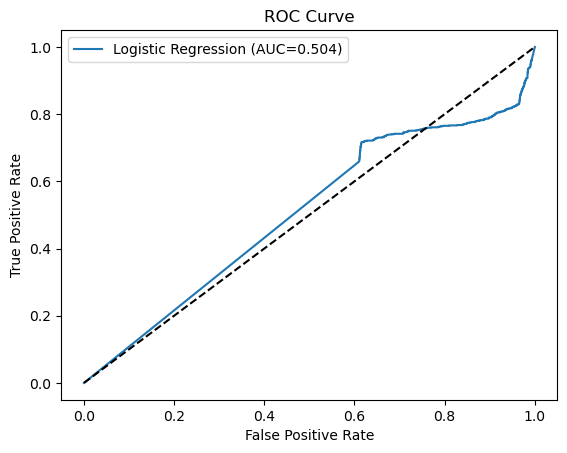


========== Logistic Regression (آستانه بهینه = 0.0000) ==========
Accuracy : 0.4217
Precision: 0.1273
Recall   : 0.7167
F1-Score : 0.2162
AUC      : 0.5040
Confusion Matrix:
[[2722 4353]
 [ 251  635]]

Classification Report (با آستانه بهینه):
              precision    recall  f1-score   support

           0       0.92      0.38      0.54      7075
           1       0.13      0.72      0.22       886

    accuracy                           0.42      7961
   macro avg       0.52      0.55      0.38      7961
weighted avg       0.83      0.42      0.51      7961



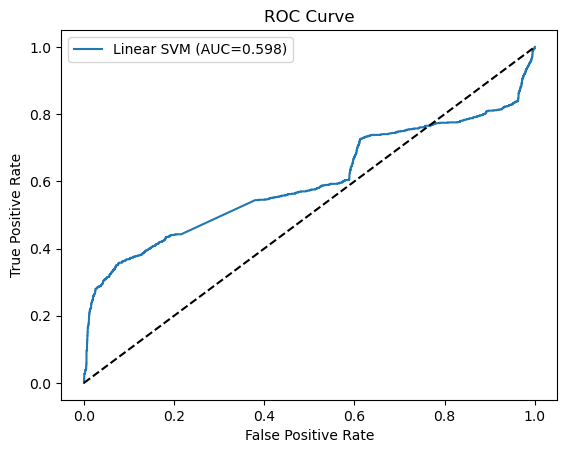


========== Linear SVM (آستانه بهینه = 0.5611) ==========
Accuracy : 0.8970
Precision: 0.5767
Recall   : 0.2799
F1-Score : 0.3769
AUC      : 0.5982
Confusion Matrix:
[[6893  182]
 [ 638  248]]

Classification Report (با آستانه بهینه):
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7075
           1       0.58      0.28      0.38       886

    accuracy                           0.90      7961
   macro avg       0.75      0.63      0.66      7961
weighted avg       0.88      0.90      0.88      7961

بهترین max_depth برای Decision Tree: 3


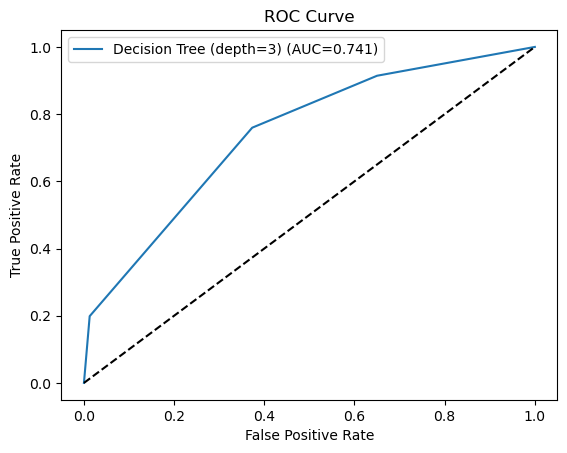


========== Decision Tree (depth=3) (آستانه بهینه = 0.3902) ==========
Accuracy : 0.6416
Precision: 0.2031
Recall   : 0.7596
F1-Score : 0.3206
AUC      : 0.7406
Confusion Matrix:
[[4435 2640]
 [ 213  673]]

Classification Report (با آستانه بهینه):
              precision    recall  f1-score   support

           0       0.95      0.63      0.76      7075
           1       0.20      0.76      0.32       886

    accuracy                           0.64      7961
   macro avg       0.58      0.69      0.54      7961
weighted avg       0.87      0.64      0.71      7961



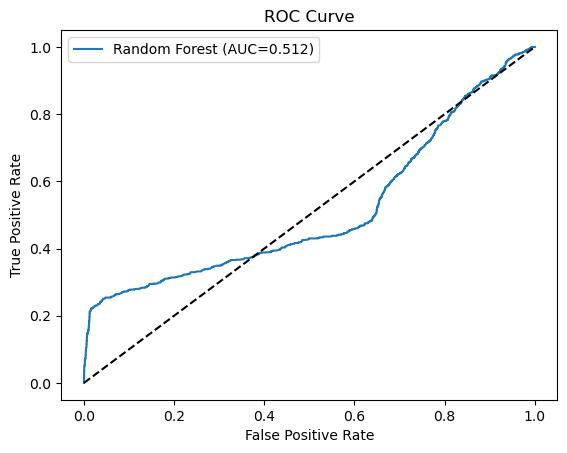


========== Random Forest (آستانه بهینه = 0.3890) ==========
Accuracy : 0.8986
Precision: 0.6254
Recall   : 0.2223
F1-Score : 0.3281
AUC      : 0.5118
Confusion Matrix:
[[6957  118]
 [ 689  197]]

Classification Report (با آستانه بهینه):
              precision    recall  f1-score   support

           0       0.91      0.98      0.95      7075
           1       0.63      0.22      0.33       886

    accuracy                           0.90      7961
   macro avg       0.77      0.60      0.64      7961
weighted avg       0.88      0.90      0.88      7961



===== جدول مقایسه مدل‌های طبقه‌بندی با آستانه بهینه (بر اساس F1) =====
                  Model  Best_Threshold  Accuracy  Precision  Recall     F1    AUC
    Logistic Regression          0.0000    0.4217     0.1273  0.7167 0.2162 0.5040
             Linear SVM          0.5611    0.8970     0.5767  0.2799 0.3769 0.5982
Decision Tree (depth=3)          0.3902    0.6416     0.2031  0.7596 0.3206 0.7406
          Random Forest       

In [17]:
def evaluate_with_threshold_tuning(model, X_train, y_train, X_test, y_test, model_name=""):
    model.fit(X_train, y_train)
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_test)
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min() + 1e-10)
    else:
        raise ValueError("مدل باید متد predict_proba یا decision_function داشته باشد.")
    unique_probs = np.unique(y_prob)
    best_f1 = 0
    best_threshold = 0.5
    for th in unique_probs:
        y_pred = (y_prob >= th).astype(int)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = th
    
    y_pred_opt = (y_prob >= best_threshold).astype(int)
    
    acc = accuracy_score(y_test, y_pred_opt)
    prec = precision_score(y_test, y_pred_opt, zero_division=0)
    rec = recall_score(y_test, y_pred_opt, zero_division=0)
    f1 = best_f1
    auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred_opt)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.3f})')
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()
    # چاپ نتایج
    print(f"\n========== {model_name} (آستانه بهینه = {best_threshold:.4f}) ==========")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"AUC      : {auc:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print("\nClassification Report (با آستانه بهینه):")
    from sklearn.metrics import classification_report
    print(classification_report(y_test, y_pred_opt, zero_division=0))
    
    return {'Model': model_name, 'Best_Threshold': best_threshold,
            'Accuracy': acc, 'Precision': prec, 'Recall': rec,
            'F1': f1, 'AUC': auc}

results_tuned = []

log_reg = LogisticRegression(max_iter=1000, random_state=42)
results_tuned.append(evaluate_with_threshold_tuning(log_reg, X_train_linear_scaled, y_train_linear,
                                                    X_test_linear_scaled, y_test_linear,
                                                    "Logistic Regression"))

linear_svm = SVC(kernel='linear', probability=True, random_state=42)
results_tuned.append(evaluate_with_threshold_tuning(linear_svm, X_train_linear_scaled, y_train_linear,
                                                    X_test_linear_scaled, y_test_linear,
                                                    "Linear SVM"))


dt_param = {'max_depth': [3, 4,6,5, 7, 10]}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_param, cv=3, scoring='accuracy')
dt_grid.fit(X_train_linear_scaled, y_train_linear)
best_dt = dt_grid.best_estimator_
print(f"بهترین max_depth برای Decision Tree: {best_dt.max_depth}")
results_tuned.append(evaluate_with_threshold_tuning(best_dt, X_train_linear_scaled, y_train_linear,
                                                    X_test_linear_scaled, y_test_linear,
                                                    f"Decision Tree (depth={best_dt.max_depth})"))

rf = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42, n_jobs=-1)
results_tuned.append(evaluate_with_threshold_tuning(rf, X_train_linear_scaled, y_train_linear,
                                                    X_test_linear_scaled, y_test_linear,
                                                    "Random Forest"))

df_tuned = pd.DataFrame(results_tuned)
print("\n\n===== جدول مقایسه مدل‌های طبقه‌بندی با آستانه بهینه (بر اساس F1) =====")
print(df_tuned.round(4).to_string(index=False))


========== بهینه‌سازی KNN ==========
حجم داده پس از undersampling: 9602
توزیع کلاس‌ها: مثبت=3601 , منفی=6001
Fitting 3 folds for each of 24 candidates, totalling 72 fits
بهترین پارامترهای KNN: {'n_neighbors': 15, 'p': 1, 'weights': 'uniform'}
بهترین آستانه برای KNN: 0.8000 (F1 = 0.2902)

=== KNN (آستانه بهینه) ===
Accuracy : 0.8304
Precision: 0.2717
Recall   : 0.3115
F1-Score : 0.2902
AUC      : 0.6626
Confusion Matrix:
[[6335  740]
 [ 610  276]]

Classification Report (با آستانه بهینه):
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      7075
           1       0.27      0.31      0.29       886

    accuracy                           0.83      7961
   macro avg       0.59      0.60      0.60      7961
weighted avg       0.84      0.83      0.84      7961



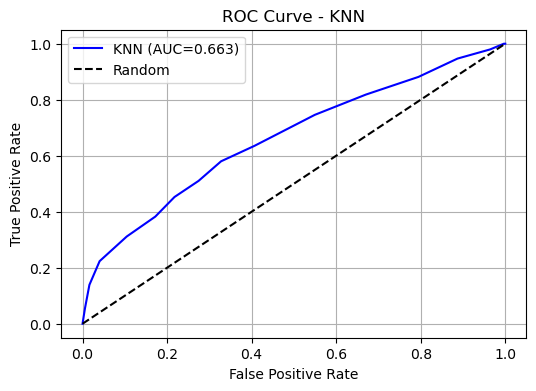

In [20]:
print("\n========== بهینه‌سازی KNN ==========")

rus_knn = RandomUnderSampler(random_state=42, sampling_strategy=0.6)
X_res_knn, y_res_knn = rus_knn.fit_resample(X_train_linear_scaled, y_train_linear)
print(f"حجم داده پس از undersampling: {X_res_knn.shape[0]}")
print(f"توزیع کلاس‌ها: مثبت={np.sum(y_res_knn)} , منفی={len(y_res_knn)-np.sum(y_res_knn)}")

param_knn = {
    'n_neighbors': [3, 5, 7, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]   
}
knn = KNeighborsClassifier()
grid_knn = GridSearchCV(knn, param_knn, cv=3, scoring='f1', n_jobs=-1, verbose=1)
grid_knn.fit(X_res_knn, y_res_knn)

best_knn = grid_knn.best_estimator_
print(f"بهترین پارامترهای KNN: {grid_knn.best_params_}")

if hasattr(best_knn, "predict_proba"):
    y_prob_knn = best_knn.predict_proba(X_test_linear_scaled)[:, 1]
else:
    y_prob_knn = best_knn.predict_proba(X_test_linear_scaled)[:, 1]

unique_probs = np.unique(y_prob_knn)
best_f1 = 0
best_th = 0.5
for th in unique_probs:
    y_pred_temp = (y_prob_knn >= th).astype(int)
    f1 = f1_score(y_test_linear, y_pred_temp, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_th = th

print(f"بهترین آستانه برای KNN: {best_th:.4f} (F1 = {best_f1:.4f})")

y_pred_knn_opt = (y_prob_knn >= best_th).astype(int)
acc = accuracy_score(y_test_linear, y_pred_knn_opt)
prec = precision_score(y_test_linear, y_pred_knn_opt, zero_division=0)
rec = recall_score(y_test_linear, y_pred_knn_opt, zero_division=0)
f1 = best_f1
auc = roc_auc_score(y_test_linear, y_prob_knn)
cm = confusion_matrix(y_test_linear, y_pred_knn_opt)

print("\n=== KNN (آستانه بهینه) ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")
print("Confusion Matrix:")
print(cm)
print("\nClassification Report (با آستانه بهینه):")
print(classification_report(y_test_linear, y_pred_knn_opt, zero_division=0))

results_tuned.append({
    'Model': f"KNN (K={best_knn.n_neighbors}, weights={best_knn.weights}, p={best_knn.p})",
    'Best_Threshold': best_th,
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1': f1,
    'AUC': auc
})

fpr, tpr, _ = roc_curve(y_test_linear, y_prob_knn)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'KNN (AUC={auc:.3f})', color='blue')
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN')
plt.legend()
plt.grid(True)
plt.show()


<div dir='rtl'>
    در موارد بالا مشاهده می‌کنید 6 نوع مدل مختلف برای binary classification پیاده‌سازی شده‌اند.
    <br>
    برای انتخاب بهترین مدل پیاده‌سازی شده میتوان دو رویکرد رو پیش برد. یکی برای اینکه بهترین precision رو بیابیم یعنی از نتایج بدست امده از مدل روی داده های تست سعی کنیم مدلی رو بیابیم که همه پاسخ‌هایی که بدست می‌اید از کلاس y=1 باشند در این صورت از انجا که این مسئله برروی داده‌های بانکی پیاده سازی شده‌اند می‌توان گفت در نهایت می‌توانیم که هزینه و وقت بیشتری روی این مشتریان صرف کنیم زیرا تقریبا از افتتاح حساب بلند مدت مطمئن هستیم ولی مشریان زیادی هم وجود خواهند داشت که در حالت عادی حساب را باز خواهند ولی در این مدل بدلیل کاهش توجه ممکن است از دست بروند 
    <br>
    در مدل دیگر می‌توانیم معیار را برروی recall قرار دهیم اینگونه مطمئن هستیم مشتریانی که در نهایت حساب باز خوهند کرد تقریبا در نتایج اخر وجود دارند اما با افزایش recall در مدل‌ها precision پایین می‌اید که تعداد مراجعینی که روی انها کار انجام می‌شود زیادتر می‌شوند ولی مراجعان کمی از دست می‌روند
    <br>
    در منطق مدل هایی که پیاده کردم سعی کردم از بیشترین و کمترین مقدار‌های تخمینی برای  نتیجه استفاده کنم و بهترین thershold  رو انتخاب کنم.می‌شود با تغییر این ضریب مقادیر دیگر رو نیز بدست اورد ولی خب با کم و زیاد کردن ان مدل به نتیجه‌گیری صفر و صدی نزدیک می‌شود 
    <br>دلیل اصلی اینکه مدل‌ها auc در بیشتر مدل ها کم می‌باشد یکی عدم توازن خوب نتیجه می‌باشد.تقریبا از هر 10 داده تنها 1 داده به پاسخ مثبت تعلق دارد که البته در دنیا واقعی همینگونه می‌باشد اما برای ساخت مدل ها بهتر بود که داده‌ها  مثبت oversampling می‌شد یا داده‌ها منفی under sampling  می‌شدند که البته مورد اول در این دیتا سخت بود چون پراکندگی نتیجه مثبت براساس ویژگی‌ها بسیار زیاد و در نتیجه برای هر مقدار در ویژگی تعداد محدودی نتیجه مثبت وجود داشت برای نمونه در بازه سنی زیر 20 سال تنها 30 نمونه وجود دااشت که نتیجه مثبت داشته باشند ولی در کل در این بازه 100 نمونه بود که تازه این بازه یکی از بهترین نتیجه ها با مقدار تقریببی 70 درصد برای recall بود.

<p dir="rtl" style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; line-height: 1.6; text-align: justify;">
در Naive Bayes، احتمال پسین مستقل از ویژگی‌ها محاسبه می‌شود. در داده‌ی نامتوازن، اگر در داده‌ی آموزش، میانگین ویژگی‌ها در کلاس مثبت و منفی تفاوت معنی‌داری نداشته باشد، احتمال پیشین (۱۱٪) می‌تواند باعث غلبه کلاس مثبت نشود، اما ممکن است مقادیر ویژگی‌ها در زیرمجموعه‌ی متوازن شده نیز تفکیک‌کننده نباشند. در اینجا، <code style="background-color: #f4f4f4; padding: 2px 4px; border-radius: 4px;">predict_proba</code> برای همه نمونه‌ها مقدار ۱ برگردانده است که نشان می‌دهد مدل صد در صد مطمئن از مثبت بودن همه نمونه‌هاست. این نشانه‌ی وجود مشکل در محاسبات عددی یا عدم تفکیک‌پذیری کامل است.
</p>
<div dir='rtl'>
    در مدل knn نیز بدلیل اینکه دادهای کلاس اکثریت غالب می‌باشند از under sampling استفاده کردم.

حجم داده پس از undersampling: 10803
توزیع کلاس‌ها: مثبت=3601 , منفی=7202
Fitting 3 folds for each of 16 candidates, totalling 48 fits
بهترین پارامترها: {'C': 0.5, 'gamma': 'auto', 'kernel': 'rbf'}
بهترین آستانه: 0.6348 (F1 = 0.2003)

=== Kernel SVM (RBF) با تنظیم بهینه ===
Accuracy : 0.1113
Precision: 0.1113
Recall   : 1.0000
F1-Score : 0.2003
AUC      : 0.5000
Confusion Matrix:
[[   0 7075]
 [   0  886]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      7075
           1       0.11      1.00      0.20       886

    accuracy                           0.11      7961
   macro avg       0.06      0.50      0.10      7961
weighted avg       0.01      0.11      0.02      7961



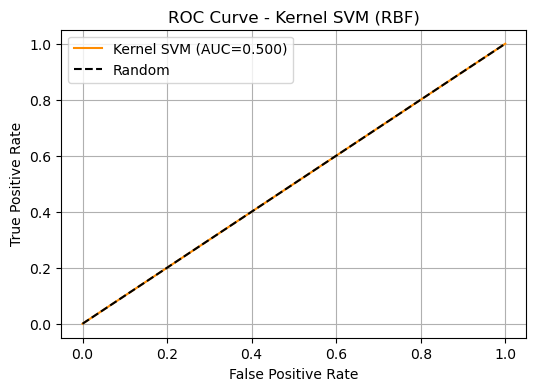

In [23]:

rus = RandomUnderSampler(sampling_strategy=0.5, random_state=42)
X_res, y_res = rus.fit_resample(X_train_linear_scaled, y_train_linear)
print(f"حجم داده پس از undersampling: {X_res.shape[0]}")
print(f"توزیع کلاس‌ها: مثبت={np.sum(y_res)} , منفی={len(y_res)-np.sum(y_res)}")

param_grid = {
    'C': [0.5, 1, 5, 10],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf']
}
svm = SVC(probability=True, random_state=42, class_weight='balanced')
grid = GridSearchCV(svm, param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1)
grid.fit(X_res, y_res)

best_svm = grid.best_estimator_
print(f"بهترین پارامترها: {grid.best_params_}")

y_prob = best_svm.predict_proba(X_test_linear_scaled)[:, 1]

unique_probs = np.unique(y_prob)
best_f1 = 0
best_th = 0.5
for th in unique_probs:
    y_pred_temp = (y_prob >= th).astype(int)
    f1 = f1_score(y_test_linear, y_pred_temp, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_th = th

print(f"بهترین آستانه: {best_th:.4f} (F1 = {best_f1:.4f})")

y_pred_opt = (y_prob >= best_th).astype(int)
acc = accuracy_score(y_test_linear, y_pred_opt)
prec = precision_score(y_test_linear, y_pred_opt, zero_division=0)
rec = recall_score(y_test_linear, y_pred_opt, zero_division=0)
f1 = best_f1
auc = roc_auc_score(y_test_linear, y_prob)
cm = confusion_matrix(y_test_linear, y_pred_opt)

print("\n=== Kernel SVM (RBF) با تنظیم بهینه ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test_linear, y_pred_opt, zero_division=0))

fpr, tpr, _ = roc_curve(y_test_linear, y_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'Kernel SVM (AUC={auc:.3f})', color='darkorange')
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Kernel SVM (RBF)')
plt.legend()
plt.grid(True)
plt.show()

results_tuned.append({
    'Model': 'Kernel SVM (RBF, tuned)',
    'Best_Threshold': best_th,
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1': f1,
    'AUC': auc
})

========== XGBoost برای طبقه‌بندی باینری ==========
Fitting 3 folds for each of 12 candidates, totalling 36 fits
بهترین پارامترها: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200, 'scale_pos_weight': 7.842543737850597}
بهترین آستانه برای XGBoost: 0.4302 (F1 = 0.2572)

=== XGBoost (آستانه بهینه) ===
Accuracy : 0.7287
Precision: 0.1850
Recall   : 0.4221
F1-Score : 0.2572
AUC      : 0.6202
Confusion Matrix:
[[5427 1648]
 [ 512  374]]

Classification Report (با آستانه بهینه):
              precision    recall  f1-score   support

           0       0.91      0.77      0.83      7075
           1       0.18      0.42      0.26       886

    accuracy                           0.73      7961
   macro avg       0.55      0.59      0.55      7961
weighted avg       0.83      0.73      0.77      7961



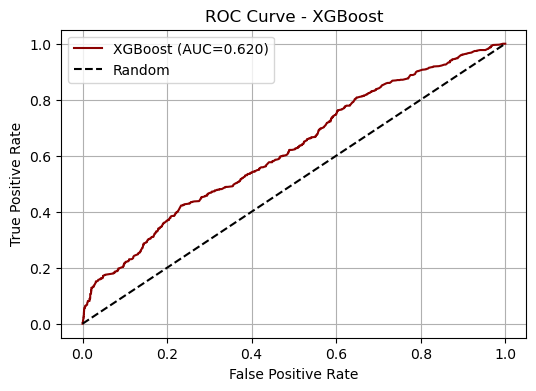

In [25]:
print("========== XGBoost برای طبقه‌بندی باینری ==========")
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'scale_pos_weight': [ (len(y_train_linear) - sum(y_train_linear)) / sum(y_train_linear) ]
}
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
grid = GridSearchCV(xgb_model, param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1)
grid.fit(X_train_linear_scaled, y_train_linear)

best_xgb = grid.best_estimator_
print(f"بهترین پارامترها: {grid.best_params_}")

y_prob = best_xgb.predict_proba(X_test_linear_scaled)[:, 1]
unique_probs = np.unique(y_prob)
best_f1 = 0
best_th = 0.5
for th in unique_probs:
    y_pred_temp = (y_prob >= th).astype(int)
    f1 = f1_score(y_test_linear, y_pred_temp, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_th = th

print(f"بهترین آستانه برای XGBoost: {best_th:.4f} (F1 = {best_f1:.4f})")
y_pred_opt = (y_prob >= best_th).astype(int)
acc = accuracy_score(y_test_linear, y_pred_opt)
prec = precision_score(y_test_linear, y_pred_opt, zero_division=0)
rec = recall_score(y_test_linear, y_pred_opt, zero_division=0)
f1 = best_f1
auc = roc_auc_score(y_test_linear, y_prob)
cm = confusion_matrix(y_test_linear, y_pred_opt)

print("\n=== XGBoost ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")
print("Confusion Matrix:")
print(cm)
print("\nClassification Report :")
print(classification_report(y_test_linear, y_pred_opt, zero_division=0))
fpr, tpr, _ = roc_curve(y_test_linear, y_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'XGBoost (AUC={auc:.3f})', color='darkred')
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.grid(True)
plt.show()

if 'results_tuned' not in dir():
    results_tuned = []
results_tuned.append({
    'Model': 'XGBoost',
    'Best_Threshold': best_th,
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1': f1,
    'AUC': auc
})

<div class="container">
    <div dir='ltr'>
    <h2>Question 1: Choose the best classification metric for your dataset and justify.</h2>
    <div dir="rtl">
    پاسخ:<br>
    برای مجموعه داده بازاریابی بانکی که به شدت نامتوازن است (تنها حدود ۱۱.۳٪ داده‌ها مثبت هستند)، معیارهای <strong>AUC-ROC</strong> و <strong>F1-Score</strong> بهترین انتخاب هستند.
    <ul>
        <li><strong>دلیل رد Accuracy:</strong> معیار دقت کل (Accuracy) در داده‌های نامتوازن کاملاً فریب‌دهنده است. به عنوان مثال، مدل Kernel SVM در خروجی برای راحتی کار همه نمونه‌ها را صفر پیش‌بینی کرد و به دقت کل <span class="math">88.87%</span> رسید! این دقت بالا بی‌ارزش است چون مدل حتی یک مشتری واقعی را هم پیدا نکرده است.</li>
        <li><strong>توجیه انتخاب AUC-ROC:</strong> این معیار توانایی کلی مدل را در تفکیک دو کلاس مثبت و منفی در تمامی آستانه‌های تصمیم‌گیری ممکن می‌سنجد و تحت تأثیر توزیع نامتوازن داده‌ها قرار نمی‌گیرد (مدل درخت تصمیم با <span class="math">AUC=0.74</span> برنده این معیار شد).</li>
                 که در نتیجه این معیار می‌تواند بالانس بودن بین دو معیار recall , precision رو بهتر نشان بدهد یعنی اینکه تا چه میزان میتوان دو معیار ذکر شده به خوبی عمل کنند.
        <li><strong>توجیه انتخاب F1-Score:</strong> این معیار میانگین هارمونیک بین Precision (دقت مثبت‌ها) و Recall (میزان پیدا کردن مثبت‌های واقعی) است. بالا بودن F1-Score تضمین می‌کند که مدل هم در شکار مشتریان واقعی موفق بوده و هم هزینه بانک را با تماس‌های اشتباه (مثبت کاذب) هدر نداده است.</li>
         که در نتیجه این معیار می‌تواند بالانس بودن بین دو معیار recall , precision رو بهتر نشان بدهد یعنی اینکه تا چه میزان میتوان دو معیار ذکر شده به خوبی عمل کنند.
    </ul>
    <div dir='ltr'>
    <h2>Question 2: Explain 3 techniques to regularize the training process for decision trees.</h2>
    <div dir="rtl">
    <strong>پاسخ:</strong><br>
    برای اینکه یک درخت تصمیم بیش از حد بزرگ نشود و داده‌های آموزش را حفظ (Overfit) نکند، از روش‌های کنترل رشد یا منظم‌سازی زیر استفاده می‌شود:</p>
    <ol>
        <li><strong>محدود کردن حداکثر عمق درخت (Max Depth):</strong> تعیین یک سقف برای طول شاخه‌ها (مانند <span class="math">max_depth=3</span> که در کد بهترین نتیجه را داد). این کار مانع از آن می‌شود که درخت تا جایی رشد کند که برای تک‌تک داده‌های نویزی، برگ‌های اختصاصی و ریز بسازد.</li>
        <li><strong>حداقل نمونه برای تقسیم یک گره (Min Samples Split):</strong> تنظیم این شرط که یک گره داخلی تنها زمانی مجاز به تقسیم شدن و ایجاد شاخه‌های جدید است که تعداد مشخصی داده (مثلاً حداقل ۲۰ نمونه) در آن وجود داشته باشد.</li>
        <li><strong>هرس کردن هزینه-پیچیدگی (Cost-Complexity Pruning - <span class="math">α</span>):</strong> در این روش بعد از رشد کامل درخت، یک جریمه بر اساس تعداد برگ‌ها به تابع خطا اضافه می‌شود. الگوریتم شاخه‌های اضافی را که حذف کردنشان آسیب جدی به دقت آموزش نمی‌زند اما درخت را ساده‌تر می‌کند، قطع (Prune) می‌کند.</li>
    </ol>
    <div dir="ltr">
    <h2>Question 3: Compare Linear SVM vs Kernel SVM.</h2>
    <div dir="rtl">
    <strong>پاسخ:</strong>
    <table>
        <thead>
            <tr><th>ویژگی</th><th>SVM خطی (Linear SVM)</th><th>SVM کرنلی (Kernel SVM)</th></tr>
        </thead>
        <tbody>
            <tr><td><strong>مرز تصمیم‌گیری</strong></td><td>یک مرز یا ابرصفحه (Hyperplane) کاملاً <strong>صاف و خطی</strong> بین دو کلاس ایجاد می‌کند.</td><td>مرزهای تصمیم‌گیری <strong>پیچیده، غیرخطی و منحنی شکل</strong> متناسب با هندسه داده‌ها ایجاد می‌کند.</td></tr>
            <tr><td><strong>سرعت و محاسبات</strong></td><td>بسیار سریع است و برای داده‌هایی با ابعاد بالا (تعداد ویژگی‌های زیاد مثل متن) فوق‌العاده بهینه است.</td><td>به دلیل نیاز به محاسبه ماتریس کرنل برای تک‌تک جفت داده‌ها، در حجم داده‌های بزرگ (ردیف‌های بالا) کندتر می‌شود.</td></tr>
            <tr><td><strong>خطر اورفیت (Overfitting)</strong></td><td>ریسک اورفیت پایینی دارد اما اگر داده‌ها غیرخطی باشند دچار خطا و Underfitting می‌شود.</td><td>قدرت بالایی دارد، اما اگر پارامترهای آن (مانند <span class="math">C</span> یا <span class="math">γ</span>) به درستی تنظیم نشوند، سریعاً به مرزهای داده‌های آموزش چسبیده و اورفیت می‌شود.</td></tr>
            <tr><td><strong>موقعیت ترجیحی</strong></td><td>زمانی که داده‌ها با یک خط صاف قابل جدا شدن باشند یا تعداد ویژگی‌ها از تعداد ردیف‌ها بیشتر باشد.</td><td>زمانی که مرز میان دو کلاس در فضای خام ورودی، کاملاً درهم‌تنیده و خمیده باشد .</td></tr>
        </tbody>
    </table>
    <hr>
</div>
</body>
<div dir = 'rtl'>
    <h2>نتیحه:</h2>
    در اینجا باز هم decision tree  بهترین کلاس بود و در ادامه ان xgboost , knn, linear svm  قرار دارند.
    <br>در اینجا باز هم مشکل پراکندگی داده‌ها و کم بودن داده‌های کلاس اقلیت باعث شد که kernel svm حتی در ابعاد بالاتر هم نتواند کلاس هارا از هم تشخیص دهد و با خط انها از هم جدا کند یکی از دلایل دیگر این اتفاق ان است که بیشتر داده های موثر برای طبقه بندی بیشتر پارامتری نیستند در نتیجه نمیتوان انها رو به صورت خطی از هم جدا کرد.

In [13]:
print("--- آماده‌سازی داده‌های چندکلاسی ---")
df_train_raw = bank_CleanData.copy()
df_test_raw = test_data.copy()

y_train_multi_str = df_train_raw['age_group'].astype(str)
y_test_multi_str = df_test_raw['age_group'].astype(str)

le_multi = LabelEncoder()
y_train_multi = le_multi.fit_transform(y_train_multi_str)
y_test_multi = le_multi.transform(y_test_multi_str)

cols_to_drop = ['age_group']
X_train_multi_df = df_train_raw.drop(columns=cols_to_drop, errors='ignore')
X_test_multi_df = df_test_raw.drop(columns=cols_to_drop, errors='ignore')

if 'pdays_real' in X_train_multi_df.columns:
    X_train_multi_df['pdays_real'] = X_train_multi_df['pdays_real'].fillna(-1)
if 'pdays_real' in X_test_multi_df.columns:
    X_test_multi_df['pdays_real'] = X_test_multi_df['pdays_real'].fillna(-1)

X_train_multi_df = X_train_multi_df.select_dtypes(include=[np.number, bool]).astype(float)
X_test_multi_df = X_test_multi_df.select_dtypes(include=[np.number, bool]).astype(float)
X_test_multi_df = X_test_multi_df.reindex(columns=X_train_multi_df.columns, fill_value=0.0)

X_train_multi = X_train_multi_df.values
X_test_multi = X_test_multi_df.values

def evaluate_multiclass(model, X_train, y_train, X_test, y_test, name, requires_proba=True):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    loss = None
    if requires_proba and hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)
        loss = log_loss(y_test, y_prob, labels=np.unique(y_train))
    
    print(f"\n{'='*60}\n {name}\n{'='*60}")
    print(classification_report(y_test, y_pred, target_names=le_multi.classes_, zero_division=0))
    print("🔹 Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    return {'Model': name, 'Accuracy': acc, 'F1-Macro': f1_macro, 'F1-Weighted': f1_weighted, 'Log Loss': loss}

multiclass_results = []

multiclass_results.append(evaluate_multiclass(
    LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42),
    X_train_multi, y_train_multi, X_test_multi, y_test_multi,
    "Multinomial Logistic Regression"
))

multiclass_results.append(evaluate_multiclass(
    DecisionTreeClassifier(max_depth=5, random_state=42),
    X_train_multi, y_train_multi, X_test_multi, y_test_multi,
    "Decision Tree"
))

multiclass_results.append(evaluate_multiclass(
    XGBClassifier(eval_metric='mlogloss', random_state=42),
    X_train_multi, y_train_multi, X_test_multi, y_test_multi,
    "XGBoost"
))
multiclass_results.append(evaluate_multiclass(
    LGBMClassifier(random_state=42, verbose=-1),
    X_train_multi, y_train_multi, X_test_multi, y_test_multi,
    "LightGBM"
))
multiclass_results.append(evaluate_multiclass(
    CatBoostClassifier(iterations=100, verbose=0, random_state=42),
    X_train_multi, y_train_multi, X_test_multi, y_test_multi,
    "CatBoost"
))
subset_size = 8000
indices = np.random.choice(len(X_train_multi), subset_size, replace=False)
X_sub = X_train_multi[indices]
y_sub = y_train_multi[indices]

multiclass_results.append(evaluate_multiclass(
    OneVsRestClassifier(SVC(kernel='linear', probability=False, random_state=42)),
    X_sub, y_sub, X_test_multi, y_test_multi,
    "SVM (Linear, OVR, subset)"
))

multiclass_results.append(evaluate_multiclass(
    OneVsRestClassifier(SVC(kernel='rbf', probability=False, random_state=42)),
    X_sub, y_sub, X_test_multi, y_test_multi,
    "SVM (RBF, OVR, subset)"
))

multiclass_results.append(evaluate_multiclass(
    KNeighborsClassifier(n_neighbors=15),
    X_train_multi, y_train_multi, X_test_multi, y_test_multi,
    "KNN (K=15)"
))

multiclass_results.append(evaluate_multiclass(
    AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=100, random_state=42),
    X_train_multi, y_train_multi, X_test_multi, y_test_multi,
    "AdaBoost"
))

multiclass_results.append(evaluate_multiclass(
    OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42)),
    X_train_multi, y_train_multi, X_test_multi, y_test_multi,
    "Logistic Regression (OVR)"
))

df_multi_final = pd.DataFrame(multiclass_results)
print("\n\n=========================================================================")
print("  جدول مقایسه نهایی معیارهای کلی طبقه‌بندی چندکلاسی (گروه سنی)")
print("=========================================================================")
print(df_multi_final.round(4).to_string(index=False))

--- آماده‌سازی داده‌های چندکلاسی ---

📊 Multinomial Logistic Regression
              precision    recall  f1-score   support

       19-29       0.14      1.00      0.24      1110
       29-39       0.00      0.00      0.00      3375
       39-49       0.00      0.00      0.00      1970
       49-59       0.00      0.00      0.00      1280
         <19       0.00      0.00      0.00         6
         <60       0.00      0.00      0.00       220

    accuracy                           0.14      7961
   macro avg       0.02      0.17      0.04      7961
weighted avg       0.02      0.14      0.03      7961

🔹 Confusion Matrix:
[[1110    0    0    0    0    0]
 [3375    0    0    0    0    0]
 [1970    0    0    0    0    0]
 [1280    0    0    0    0    0]
 [   6    0    0    0    0    0]
 [ 220    0    0    0    0    0]]

📊 Decision Tree
              precision    recall  f1-score   support

       19-29       0.68      0.08      0.15      1110
       29-39       0.46      0.93      0

In [14]:


print("--- آزمایشگاه بزرگ مقایسه روش‌های متعادل‌سازی چندکلاسی ---")

df_train_raw = bank_CleanData.copy()
df_test_raw = test_data.copy()

y_train_multi_str = df_train_raw['age_group'].astype(str)
y_test_multi_str = df_test_raw['age_group'].astype(str)

le_multi = LabelEncoder()
y_train_multi = le_multi.fit_transform(y_train_multi_str)
y_test_multi = le_multi.transform(y_test_multi_str)

cols_to_drop = ['age_group', 'total_contacts_bin', 'ratio_bin']
X_train_multi_df = df_train_raw.drop(columns=cols_to_drop, errors='ignore').select_dtypes(include=[np.number, bool]).astype(float)
X_test_multi_df = df_test_raw.drop(columns=cols_to_drop, errors='ignore').select_dtypes(include=[np.number, bool]).astype(float)

if 'pdays_real' in X_train_multi_df.columns:
    X_train_multi_df['pdays_real'] = X_train_multi_df['pdays_real'].fillna(-1)
if 'pdays_real' in X_test_multi_df.columns:
    X_test_multi_df['pdays_real'] = X_test_multi_df['pdays_real'].fillna(-1)

X_test_multi_df = X_test_multi_df.reindex(columns=X_train_multi_df.columns, fill_value=0.0)

X_train_base = X_train_multi_df.values
X_test_base = X_test_multi_df.values

unique, counts = np.unique(y_train_multi, return_counts=True)
minority_class_label = unique[np.argmin(counts)]
minority_count = np.min(counts)
strategies = {
    "1. Tomek Links (Smart Undersampling)": TomekLinks(sampling_strategy='not minority'),
    
    "2. SMOTE + Tomek (Hybrid Method)": SMOTETomek(smote=SMOTE(k_neighbors=1, random_state=42), random_state=42),
    
    "3. Aggressive Random Undersampling": RandomUnderSampler(
        sampling_strategy={u: min(c, 1200) if u != minority_class_label else c for u, c in zip(unique, counts)}, 
        random_state=42
    ),
    
    "4. Pure SMOTE (Full Data)": SMOTE(k_neighbors=1, random_state=42)
}

experiment_results = []

for strat_name, sampler in strategies.items():
    print(f"\n در حال اعمال استراتژی: {strat_name} ...")
    try:
        X_res, y_res = sampler.fit_resample(X_train_base, y_train_multi)
        print(f"   🔹 حجم داده تمرین پس از اعمال این روش: {len(X_res)} ردیف")
        
        for model_name, model in [("LightGBM", LGBMClassifier(random_state=42, verbose=-1)), 
                                  ("CatBoost", CatBoostClassifier(iterations=100, verbose=0, random_state=42))]:
            
            model.fit(X_res[:20000], y_res[:20000])
            y_pred = model.predict(X_test_base)
            
            acc = accuracy_score(y_test_multi, y_pred)
            f1_w = f1_score(y_test_multi, y_pred, average='weighted', zero_division=0)
            f1_m = f1_score(y_test_multi, y_pred, average='macro', zero_division=0)
            
            experiment_results.append({
                'Sampling Strategy': strat_name,
                'Model': model_name,
                'Accuracy': acc,
                'F1-Weighted': f1_w,
                'F1-Macro': f1_m
            })
    except Exception as e:
        print(f" این استراتژی به دلیل محدودیت آماری رده سنی خلوت اجرا نشد: {e}")

df_experiment_final = pd.DataFrame(experiment_results)
print("\n\n=========================================================================================")
print("  جدول مقایسه کلان متدهای مختلف UNDERSAMPLING و OVERSAMPLING")
print("=========================================================================================")
print(df_experiment_final.round(4).to_string(index=False))

--- 🧪 آزمایشگاه بزرگ مقایسه روش‌های متعادل‌سازی چندکلاسی ---

⚡ در حال اعمال استراتژی: 1. Tomek Links (Smart Undersampling) ...
   🔹 حجم داده تمرین پس از اعمال این روش: 28820 ردیف

⚡ در حال اعمال استراتژی: 2. SMOTE + Tomek (Hybrid Method) ...
   🔹 حجم داده تمرین پس از اعمال این روش: 75790 ردیف

⚡ در حال اعمال استراتژی: 3. Aggressive Random Undersampling ...
   🔹 حجم داده تمرین پس از اعمال این روش: 5778 ردیف

⚡ در حال اعمال استراتژی: 4. Pure SMOTE (Full Data) ...
   🔹 حجم داده تمرین پس از اعمال این روش: 78318 ردیف


 🏁 جدول مقایسه کلان متدهای مختلف UNDERSAMPLING و OVERSAMPLING
                   Sampling Strategy    Model  Accuracy  F1-Weighted  F1-Macro
1. Tomek Links (Smart Undersampling) LightGBM    0.4105       0.3524    0.2296
1. Tomek Links (Smart Undersampling) CatBoost    0.3582       0.3001    0.2376
    2. SMOTE + Tomek (Hybrid Method) LightGBM    0.4339       0.3153    0.1654
    2. SMOTE + Tomek (Hybrid Method) CatBoost    0.4062       0.3652    0.2846
  3. Aggressive Random


<body>
    
<div class="container">
<div dir = 'rtl'>
    <!-- ========================= بخش ۱ ========================= -->
</div>
    <div dir = 'ltr'>
    <h3> Choose the best multiclass-classification metric for your dataset and justify.</h3>
    </div> <div dir='rtl'>
    <strong>پاسخ و تحلیل مهندسی داده‌ها:</strong>
    برای این مسئله طبقه‌بندی چندکلاسی پیش‌بینی گروه‌های سنی، معیار <strong>F1-Macro</strong> دقیق‌ترین و منصفانه‌ترین معیار برای ارزیابی عملکرد مدل‌ها است.   
    <ul>
        <li><strong>دلیل رد Accuracy:</strong> طبق نتایج آزمایش، مدل <code>LightGBM</code> روی استراتژی <code>Tomek Links</code> دقت کل \(41.05\%\) را ثبت کرده است، اما معیار <code>F1-Macro</code> آن تنها \(0.2296\) است. این تناقض نشان می‌دهد که به دلیل عدم توازن شدید داده‌ها (وجود کلاسی با تنها ۶ نمونه در مقابل کلاس اکثریت با بیش از ۳ هزار نمونه)، مدل‌ها تمایل دارند بیشتر پیش‌بینی‌ها را به سمت کلاس اکثریت بفرستند تا ظاهر دقت کل را بالا نگه دارند. پس Accuracy کاملاً فریب‌دهنده است.</li>
        <li><strong>توجیه انتخاب F1-Macro و تعیین متد برتر:</strong> معیار <code>F1-Macro</code> بدون توجه به جمعیت کلاس‌ها، به عملکرد مدل در تک‌تک کلاس‌ها وزن یکسان می‌دهد. طبق جدول نتایج تجربی ما، <strong>استراتژی ترکیبی SMOTE + Tomek به همراه مدل CatBoost</strong> با ثبت بالاترین شاخص <strong>F1-Macro = 0.2846</strong> برنده قطعی آزمایش است. این روش ابتدا با ابزار SMOTE داده‌های خلوت را تکثیر کرده و سپس با حذف زوج‌داده‌های مبهم مرزی توسط <code>Tomek Links</code>، یک فضای تفکیک‌پذیر و بهینه برای ساختار غیرخطی درخت‌های تصمیم متمایز CatBoost ایجاد کرده است. در مقابل، روش <code>Aggressive Undersampling</code> به دلیل حذف بیش از ۸۰٪ داده‌های واقعی آموزش و ایجاد پدیده Underfitting، با افت شدید عملکرد مواجه شد.</li>
    </ul>
    <hr>
    <!-- ========================= بخش ۲ ========================= -->
    </div><div dir='ltr'>
        <h3> Explain how KNN and Decision Trees can be extended to multi-label classification problems.</h3>
    </div><div dir='rtl'>
        <strong>پاسخ:</strong>
    الگوریتم‌های KNN و درخت تصمیم می‌توانند از حالت تک‌متغیره خارج شده و به صورت ساختاری برای مسائل <strong>چندبرچسبی (Multi-label)</strong> — جایی که یک نمونه هم‌زمان می‌تواند به چند دسته مستقل تعلق داشته باشد — توسعه یابند:
    <ol>
        <li><strong>توسعه KNN به Multi-label (روش ML-KNN):</strong> در این متد، ابتدا برای هر نمونه جدید، \(K\) همسایه نزدیک آن در فضای ویژگی پیدا می‌شود. سپس به جای رأی‌گیری اکثریت ساده، برای هر برچسب به طور کاملاً مستقل فرآیند شمارش را انجام می‌دهد. در نهایت با استفاده از قضیه بیز (Bayesian Inference) و محاسبه احتمال پسین تعلق نمونه به برچسب بر اساس وضعیت همسایگان واجد شرایط، تصمیم می‌گیرد که آیا آن برچسب خاص به نمونه تعلق می‌گیرد یا خیر.</li>
        <li><strong>توسعه Decision Tree به Multi-label:</strong> در یک درخت تصمیم چندبرچسبی، نحوه محاسبه خلوص در گره‌ها (Gini Criterion یا Entropy) تغییر می‌کند. به جای سنجش خلوص برای یک ستون هدف، معیار ناخالصی به صورت <strong>میانگین آنتروپی روی تمامی برچسب‌های هدف موجود</strong> محاسبه می‌شود تا بهترین ویژگی برای شکستن گره انتخاب گردد. در برگ‌های انتهایی این درخت نیز به جای یک کلاس واحد، یک بردار باینری (مانند <code>[1, 0, 1, 1]</code>) ثبت می‌شود که وضعیت هم‌زمان تمام برچسب‌ها را نشان می‌دهد.</li>
    </ol>
    <hr> 
    <!-- ========================= بخش ۳ ========================= -->
        <div dir='ltr'>
        <h3> Suppose we have a multi-label classification problem in football, where each player can belong to ...</h3>
    <div dir='rtl'>
            <strong>پاسخ:</strong>
    در سناریوی چندبرچسبی بازیکنان فوتبال (شامل برچسب‌های: سابقه ملی، بیماری قلبی، آسیب زانو و سابقه کاپیتانی)، هر کلاس ماهیت علمی و اهمیت مستقل خود را دارد.
    <ul>
        <li><strong>چرا معیار Subset Accuracy (Exact Match Ratio) برای این مسئله غلط است؟</strong> در معیار Subset Accuracy، اگر مدل از ۴ برچسب یک بازیکن، ۳ مورد را کاملاً درست تشخیص دهد و تنها در یک مورد (مثلاً سابقه کاپیتانی) اشتباه کند، امتیاز کل آن بازیکن را <strong>صفر</strong> لحاظ می‌کند. این کار ارزیابی مربی یا الگوریتم را به شدت سخت‌گیرانه و غیرواقعی می‌کند و بهبودهای تدریجی مدل در تشخیص موارد حیاتی (مثل عارضه قلبی) را نادیده می‌گیرد.</li>
        <li><strong>معیار پیشنهادی اول: Samples Average F1-Score</strong><br>
        این معیار عملکرد مدل را روی تک‌تک بازیکنان به صورت مجزا بر اساس تعادل پرسیژن و ریکال برچسب‌هایشان می‌سنجد و سپس میانگین کل می‌گیرد. اگر مدل بخشی از برچسب‌های یک بازیکن را درست حدس بزند، امتیاز متناسب با آن را دریافت می‌کند که مزیتی بزرگ برای ارزیابی منصفانه است.</li>
        <li><strong>معیار پیشنهادی دوم: Hamming Loss</strong><br>
        این معیار نرخ کل برچسب‌های اشتباه پیش‌بینی‌شده (غلط‌های مثبت کاذب و منفی کاذب در تمام کلاس‌ها) را نسبت به کل حجم تصمیم‌گیری‌ها محاسبه می‌کند:
        <div class="math-block">
            \[
            \text{Hamming Loss} = \frac{1}{N \times L} \sum_{i=1}^{N} \sum_{j=1}^{L} I(y_{i,j} \neq \hat{y}_{i,j})
            \]
        </div>
        این معیار مشخص می‌کند که الگوریتم در چند درصد از تک‌تصمیم‌های مستقل خود روی ویژگی‌های فیزیکی و تجربی بازیکنان دچار خطا شده است و معیار بسیار پایدارتری برای داده‌های چندبرچسبی است.</li>
    </ul>
    <div class="metric-badge">
         <strong>خلاصه:</strong> در مسائل چندکلاسی نامتوازن <strong>F1-Macro</strong> معیار قابل اعتماد است. برای توسعه KNN و درخت تصمیم به فضای چندبرچسبی، به ترتیب <strong>ML-KNN</strong> و <strong>معیار ناخالصی میانگین آنتروپی</strong> راهکارهای استاندارد هستند. در ارزیابی مسائل چندبرچسبی، <strong>Samples F1-Score</strong> و <strong>Hamming Loss</strong> نسبت به دقت زیرمجموعه (Exact Match) ارجحیت دارند.
    </div>
</div>
</body>
</html>


<div dir = 'rtl'>
    در ادامه نیز سعی کردم که برای دو نوع مدل CatBoost,LightGBM 3 نوع under sampling , over sampling  پیاده‌سازی کنم تا با بررسی نتیجه بهبود در معیارها نوشته شده را بررسی کنم. مشاهده می‌کنید با under sampling و  over samoling  کردن این دو مدل برعکس هم رفتار می‌کنند که با تحقیق در مورد این دو مدل دلاییل احتمالی این رفتار رو سعی کردم مشخص کنم.
<body>
<div class="box">
    <div class="summary">
        <br>
         بر اساس نتایج آزمایش روی داده‌های نامتوازن (گروه سنی):
        <ul>
            <li><strong>LightGBM</strong> در استراتژی <span class="badge">Tomek Links (Undersampling)</span> عملکرد بهتری نشان داد (F1-Weighted بالاتر). دلیل: LightGBM به داده‌های واقعی و حذف نمونه‌های منفی اضافی حساسیت مثبت دارد و با کاهش نویز، روی نمونه‌های مرزی کلاس اقلیت بهتر تمرکز می‌کند.</li>
            <li><strong>CatBoost</strong> در روش‌های <span class="badge">SMOTE + Tomek (Hybrid)</span> و <span class="badge">Pure SMOTE</span> برتر بود. علت: CatBoost به دلیل منظم‌سازی قوی و معماری متقارن، داده‌های مصنوعی حاصل از oversampling را بهتر تحمل می‌کند و از آن‌ها برای یادگیری الگوهای ظریف‌تر سود می‌برد. LightGBM در حضور داده‌های مصنوعی زیاد ممکن است بیش‌برازش کند.</li>
        </ul>
    </div>
</div>
</body>
</html>

<body>
    <div dir='ltr'>
<div class="container">
    <h2>1. Explain bias–variance trade-off in regression models</h2>
    <div class="answer">       <div dir='rtl'>
        در رگرسیون، خطای کل = <strong>بایاس² + واریانس + خطای نایقینی</strong>.  
        <strong>بایاس (Bias)</strong> خطای ناشی از ساده‌سازی بیش از حد مدل (مثلاً رگرسیون خطی روی داده غیرخطی).  
        <strong>واریانس (Variance)</strong> حساسیت مدل به تغییرات جزئی داده آموزش (مدل‌های پیچیده مانند درخت عمیق).  
        <strong>مبادله:</strong> با افزایش پیچیدگی مدل، بایاس کاهش می‌یابد اما واریانس افزایش می‌یابد. هدف یافتن نقطه‌ای است که مجموع خطا کمینه شود (تعادل بین underfitting و overfitting).
    </div><div dir='ltr'>
    <h2>2. When does Kernel Regression outperform Linear Regression</h2>
       <div dir='rtl'>
    <div class="answer">
        رگرسیون کرنل (مانند Kernel Ridge) زمانی برتر است که رابطه بین ویژگی‌ها و هدف <strong>غیرخطی، خمیده یا دارای الگوهای درهم‌تنیده</strong> باشد. رگرسیون خطی تنها روابط خطی را مدل می‌کند، در حالی که کرنل (مانند RBF) با نگاشت به فضای با ابعاد بالاتر، الگوهای غیرخطی را بدون افزایش محسوس پارامترها یاد می‌گیرد (ترفند کرنل).
    </div>
               <div dir='ltr'>
    <h2>3.Compare L1 vs L2 regularization</h2>
    <div class="answer">       <div dir='rtl'>
        <ul>
            <li><strong>Lasso (L1):</strong> جریمه جمع قدرمطلق ضرایب → ضرایب برخی ویژگی‌ها را <strong>دقیقاً صفر</strong> می‌کند → <strong>انتخاب ویژگی (feature selection)</strong> خودکار. برای داده‌های با تعداد ویژگی زیاد و فرضیه کم‌اهمیت بودن بسیاری از آن‌ها مناسب است.</li>
            <li><strong>Ridge (L2):</strong> جریمه جمع مربعات ضرایب → ضرایب را به سمت صفر میل می‌دهد اما صفر نمی‌کند → برای مقابله با <strong>چندهمخطی (multicollinearity)</strong> عالی است.</li>
        </ul>
        <strong>زمان برتری LASSO:</strong> وقتی تعداد ویژگی‌ها زیاد باشد و فقط تعداد کمی تأثیرگذار باشند (داده‌های پرتعداد اما تنک).<br>
        <strong>زمان برتری Ridge:</strong> وقتی بیشتر ویژگی‌ها به اندازه متوسطی تأثیرگذار باشند و هدف کاهش واریانس بدون حذف کامل آن‌ها باشد.<br>
        <strong>دلیل ایجاد اسپارسیتی در LASSO:</strong> تابع جریمه L1 دارای نقطه نوک تیز در صفر است، بنابراین بهینه‌سازی ضرایب را به سمت صفر دقیق سوق می‌دهد.
    </div><div dir='ltr'>
    <h2>4. Explain why MAPE is unreliable in some datasets</h2>
    <div class="answer">
            <div dir='rtl'>
        MAPE = میانگین قدرمطلق خطای نسبی درصدی. مشکلات آن:
            <ul>
                <li>اگر مقادیر واقعی صفر باشند، تقسیم بر صفر رخ می‌دهد (تعریف نشده).</li>
                <li>به خطاهای بالای مقادیر کوچک حساسیت شدید دارد (مثلاً پیش‌بینی ۱ به جای ۲، خطای نسبی ۱۰۰٪، ولی پیش‌بینی ۱۰۰۱ به جای ۱۰۰۰ خطای ۰.۱٪).</li>
                <li>در توزیع‌های چوله یا دارای مقادیر نزدیک صفر، گمراه‌کننده است.</li>
            </ul>
    </div><div dir='ltr'>
    <h2>5. Discuss the effect of outliers on regression models</h2>
    <div class="answer">
            <div dir='rtl'>
        نقاط پرت می‌توانند ضرایب رگرسیون خطی را به شدت تغییر دهند (MSE حساس است). رگرسیون ریج و لاسو تا حدی مقاوم‌ترند. رگرسیون هابر و رگرسیون کمّی (quantile) نیز مقاوم‌اند. مدل‌های مبتنی بر درخت (Random Forest) ذاتاً به نقاط پرت حساس نیستند، چون تقسیم‌بندی بر اساس مرتبه انجام می‌شود.
    </div><div dir='ltr'>
    <h2>6.. Explain the effect of class imbalance on binary metrics. Why is accuracy misleading in imbalanced
datasets</h2>
    <div class="answer">
            <div dir='rtl'>
        در داده‌های نامتوازن (مثلاً ۱٪ مثبت، ۹۹٪ منفی)، مدلی که همه نمونه‌ها را منفی پیش‌بینی کند به دقت ۹۹٪ می‌رسد، اما هیچ نمونه مثبتی را شناسایی نکرده است. از این رو معیارهایی مانند <strong>Precision, Recall, F1, AUC</strong> اهمیت بیشتری دارند، زیرا عملکرد روی کلاس اقلیت را نشان می‌دهند.
    </div><div dir='ltr'>
    <h2>7.Explain how the decision boundaries of your models differ fundamentally</h2>
    <div class="answer">    <div dir='rtl'>
        <strong>رگرسیون خطی/لوجستیک:</strong> مرز خطی (صفحه یا ابرصفحه).<br>
        <strong>SVM با کرنل RBF:</strong> مرزهای منحنی و غیرخطی پیچیده.<br>
        <strong>درخت تصمیم:</strong> مرزهای مستطیلی عمود بر محورها (محصول قوانین If-Then).<br>
        <strong>KNN:</strong> مرزهای چندضلعی وابسته به فاصله و همسایگان.<br>
        تفاوت اساسی در شکل و انعطاف‌پذیری مرز و حساسیت به مقیاس است.
    </div><div dir='ltr'>
    <h2>8.Explain how the decision boundaries of your models differ fundamentally Explain effect of K in KNN</h2>
    <div class="answer">    <div dir='rtl'>
        <strong>K کوچک (مثلاً ۱):</strong> مدل به نویز حساس است، مرزهای پیچیده و بیش‌برازش (overfitting).<br>
        <strong>K بزرگ:</strong> هموارسازی زیاد، مرز ساده، احتمال underfitting.<br>
        <strong>K بهینه:</strong> معمولاً با اعتبارسنجی متقابل (cross-validation) و معیارهایی مانند F1 یا خطا انتخاب می‌شود.
    </div><div dir='ltr'>
    <h2>9.Overfitting in Decision Trees</h2>
    <div class="answer">    <div dir='rtl'>
        <ul>
            <li><strong>چرا درخت به راحتی بیش‌برازش می‌کند؟</strong> زیرا می‌تواند تا عمق زیاد رشد کند و برگ‌هایی با یک یا دو نمونه ایجاد کند (یادگیری نویز).</li>
            <li><strong>چرا محدودیت max_depth کافی نیست؟</strong> علاوه بر عمق، معیارهای دیگری مانند حداقل نمونه برای تقسیم (min_samples_split) و حداقل نمونه در برگ (min_samples_leaf) نیز مهم هستند. تنظیم عمق به تنهایی ممکن است مانع از ایجاد شاخه‌های خیلی ریز نشود.</li>
            <li><strong>هرس کردن (Pruning):</strong> روشی که پس از رشد کامل درخت، شاخه‌هایی که تأثیر کمی بر کاهش خطا دارند حذف می‌شوند (Cost-Complexity Pruning).</li>
        </ul>
    </div><div dir='ltr'>
    <h2>10. Explain why Tree-based models are good feature selectors</h2>
    <div class="answer">    <div dir='rtl'>
        <p>درخت تصمیم و جنگل تصادفی، اهمیت ویژگی را بر اساس میزان کاهش ناخالصی (Gini impurity یا آنتروپی) که هر ویژگی در تقسیم‌بندی ایجاد می‌کند، محاسبه می‌کنند. ویژگی‌های پرتکرار در نزدیکی ریشه (بیشترین کاهش ناخالصی) مهم‌ترین هستند. بنابراین می‌توان ویژگی‌های کم‌اهمیت را کنار گذاشت.</p>
    </div><div dir='ltr'>
    <h2>11. Micro vs Macro vs Weighted F1</h2>
    <div class="answer">    <div dir='rtl'>
        <ul>
            <li><strong>Macro F1:</strong> میانگین ساده F1 کلاس‌ها (به همه کلاس‌ها وزن یکسان می‌دهد). زمانی که عملکرد روی کلاس‌های کوچک مهم است، مناسب‌تر است.</li>
            <li><strong>Weighted F1:</strong> میانگین وزنی با تعداد نمونه هر کلاس – اگر توزیع کلاس‌ها طبیعی باشد خوب است، اما در داده نامتوازن به سمت کلاس اکثریت سوگیری دارد و می‌تواند گمراه‌کننده باشد.</li>
            <li><strong>Micro F1:</strong> جمع TP و FP و FN در کلاس‌ها را محاسبه کرده و سپس F1 را می‌زند – به کلاس‌های پرتکرار تمایل بیشتری دارد زیرا عملکرد روی نمونه‌های زیاد غالب می‌شود. بنابراین <strong>کلاس‌های بزرگ را ترجیح می‌دهد</strong>.</li>
        </ul>
    </div><div dir='ltr'>
    <h2>12. Multi-label vs Multiclass</h2>
    <div class="answer">    <div dir='rtl'>
        <ul>
            <li><strong>تفاوت بنیادی:</strong> در چندکلاسی هر نمونه فقط به یک کلاس تعلق دارد. در چندبرچسبی هر نمونه می‌تواند همزمان به چند کلاس متعلق باشد.</li>
            <li><strong>فضای خروجی:</strong> چندکلاسی → یک برچسب از بین K کلاس. چندبرچسبی → یک بردار باینری طول K.</li>
            <li><strong>توابع هزینه:</strong> برای چندکلاسی معمولاً cross-entropy، برای چندبرچسبی binary cross-entropy (برای هر برچسب جداگانه).</li>
            <li><strong>آستانه‌گذاری (Thresholding):</strong> در چندبرچسبی خروجی احتمال برای هر برچسب باید با آستانه‌ای (مثلاً ۰.۵) به ۰/۱ تبدیل شود. در چندکلاسی softmax و آرگومان ماکسیمم.</li>
            <li><strong>معیارها:</strong> چندبرچسبی از Hamming loss، Samples F1، Exact Match Ratio و ... استفاده می‌کند.</li>
            <li><strong>توسعه KNN/درخت برای چندبرچسبی:</strong> KNN با روش رأی‌گیری مستقل برچسب‌ها (ML‑KNN)؛ درخت تصمیم با استفاده از معیار ناخالصی چندبرچسبی (میانگین آنتروپی برچسب‌ها).</li>
        </ul>
    </div><div dir='ltr'>
    <h2>13.Explain precision–recall trade-off</h2>
    <div class="answer">    <div dir='rtl'>
        Precision = TP / (TP+FP)  (چه نسبتی از پیش‌بینی‌های مثبت درست هستند).<br>
        Recall = TP / (TP+FN)  (چه نسبتی از نمونه‌های مثبت واقعی شناسایی شده‌اند).<br>
        معمولاً افزایش Recall با کاهش آستانه احتمال منجر به افزایش False Positive و کاهش Precision می‌شود. نقطه بهینه (مثلاً حداکثر F1) با توجه به نیاز کسب‌وکار انتخاب می‌شود: اگر هزینه False Positive زیاد باشد (مانند ایمیل اسپم)، Precision مهم‌تر است. اگر هزینه False Negative زیاد باشد (بیماری کشنده)، Recall مهم‌تر است.
    </div><div dir='ltr'>
    <h2>14. Explain ROC vs PR curve</h2>
    <div class="answer">    <div dir='rtl'>
        <strong>ROC</strong> (FPR در برابر TPR) برای داده‌های متوازن مناسب است و در نامتوازنی ممکن است خوش‌بینانه باشد.<br>
        <strong>منحنی PR</strong> (Precision در برابر Recall) برای داده‌های نامتوازن (به ویژه وقتی کلاس مثبت نادر است) اطلاعات واقعی‌تری می‌دهد و به عملکرد روی کلاس اقلیت حساس است. در مسائل بانکی با ۱۱٪ مثبت، منحنی PR معیار بهتری است.
    </div><div dir='ltr'>
    <h2>15. If you had unlimited time and resources, how would you improve your models think:</h2>
    <div class="answer">    <div dir='rtl'>
        <ul>
            <li><strong>پیش‌پردازش بهتر:</strong>  حذف نویز، کالیبراسیون احتمالات، متعادل‌سازی پیشرفته (SMOTE-ENN).</li>
            <li><strong>ویژگی‌های بهتر:</strong> مهندسی ویژگی با استفاده از دانش حوزه (ویژگی‌های تعاملی، تجمیع‌های ماهانه، شاخص‌های روند اقتصادی)، انتخاب ویژگی با RFE یا SelectFromModel.</li>
            <li><strong>مدل‌های بهتر:</strong> ensemble از مدل‌های متنوع (stacking با XGBoost، LightGBM، Random Forest)، شبکه‌های عصبی عمیق (MLP با dropout)، بهینه‌سازی هیپرپارامتر با الگوریتم‌های پیشرفته (Optuna, Bayesian Optimization).</li>
            <li><strong>معیارهای بهتر:</strong> استفاده از معیارهای اختصاصی کسب‌وکار (Cost-sensitive metrics، F-beta با بتای مناسب)، حساسیت به هزینه خطاهای نوع I و II.</li>
        </ul>
    </div>

</div>
</body>
</html>